# Exploración Estadística del Índice de Desarrollo Comunal (IIDC)

## Objetivo

Analizar la distribución, calidad y comportamiento de las variables utilizadas
para la construcción del Índice de Desarrollo Comunal de Chile (IIDC).

En esta etapa se evaluarán:

- Calidad de los datos
- Estadística descriptiva
- Distribuciones
- Correlaciones
- Outliers
- Supuestos para la construcción del índice

In [37]:
import sys
from pathlib import Path

# Agregar carpeta Python al path para poder importar Utils y Analytics
PROJECT_ROOT = Path.cwd().parents[1]
PYTHON_DIR = PROJECT_ROOT / "Python"

if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from Analytics.iidc_utils import obtener_dataset_iidc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [38]:
df = obtener_dataset_iidc()

df.head()

Dataset IIDC cargado:
(345, 26)


,anio,codigo_comuna,nombre_comuna,codigo_provincia,codigo_region,nombre_region,poblacion_total,promedio_edad,porcentaje_menores_15,porcentaje_adultos_mayores,porcentaje_discapacidad,promedio_escolaridad,porcentaje_alfabetizacion,total_hogares,porcentaje_computador,porcentaje_internet_fija,porcentaje_internet_movil,total_viviendas,promedio_personas_vivienda,porcentaje_hacinamiento,porcentaje_agua_red,porcentaje_saneamiento,porcentaje_electricidad,ingresos_municipales,ingresos_educacion,ingresos_salud
0,2025,1101,IQUIQUE,11,1,Tarapacá,199587,36.48,18.84,12.14,8.68,10.88,97.02,71344,56.54,75.10,87.61,76870,2.60,7.30,85.14,78.50,85.48,101354404.0,0.0,42862855.0
1,2025,1107,ALTO HOSPICIO,11,1,Tarapacá,142086,30.39,25.45,5.42,10.34,9.10,95.39,42399,43.02,60.02,86.28,46807,3.04,11.35,66.57,63.62,81.39,31015111.0,0.0,30327937.0
2,2025,1401,POZO ALMONTE,14,1,Tarapacá,16878,33.24,24.01,10.13,10.61,9.13,95.41,5675,37.67,38.08,84.67,11659,1.45,5.76,31.83,28.20,36.92,16823876.0,16455549.0,4359324.0
3,2025,1402,CAMIÑA,14,1,Tarapacá,1335,NaN,NaN,NaN,11.76,7.45,92.51,489,24.54,5.11,74.44,1178,1.13,6.79,11.88,2.46,38.46,3515135.0,2400679.0,795322.0
4,2025,1403,COLCHANE,14,1,Tarapacá,790,NaN,NaN,NaN,13.37,6.66,87.43,353,6.23,1.98,37.11,2218,0.36,2.52,9.02,1.49,6.58,3378014.0,1516594.0,1314362.0


## 1. Conociendo el dataset

In [39]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.info()

Filas: 345
Columnas: 26
<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   anio                        345 non-null    int64  
 1   codigo_comuna               345 non-null    int64  
 2   nombre_comuna               345 non-null    str    
 3   codigo_provincia            345 non-null    int64  
 4   codigo_region               345 non-null    int64  
 5   nombre_region               345 non-null    str    
 6   poblacion_total             345 non-null    int64  
 7   promedio_edad               295 non-null    float64
 8   porcentaje_menores_15       295 non-null    float64
 9   porcentaje_adultos_mayores  295 non-null    float64
 10  porcentaje_discapacidad     345 non-null    float64
 11  promedio_escolaridad        345 non-null    float64
 12  porcentaje_alfabetizacion   345 non-null    float64
 13  total_hogares         

## 2. Calidad de los datos

In [40]:
df.isnull().sum().sort_values(ascending=False)

porcentaje_adultos_mayores    50
porcentaje_menores_15         50
promedio_edad                 50
anio                           0
codigo_comuna                  0
nombre_comuna                  0
nombre_region                  0
codigo_region                  0
codigo_provincia               0
poblacion_total                0
porcentaje_discapacidad        0
promedio_escolaridad           0
porcentaje_alfabetizacion      0
total_hogares                  0
porcentaje_computador          0
porcentaje_internet_fija       0
porcentaje_internet_movil      0
total_viviendas                0
promedio_personas_vivienda     0
porcentaje_hacinamiento        0
porcentaje_agua_red            0
porcentaje_saneamiento         0
porcentaje_electricidad        0
ingresos_municipales           0
ingresos_educacion             0
ingresos_salud                 0
dtype: int64

## 3. Estadística descriptiva

In [41]:
variables = [

    "ingresos_municipales",

    "ingresos_educacion",

    "ingresos_salud",

    "promedio_escolaridad",

    "porcentaje_alfabetizacion",

    "porcentaje_agua_red",

    "porcentaje_saneamiento",

    "porcentaje_electricidad",

    "porcentaje_hacinamiento",

    "promedio_personas_vivienda",

    "porcentaje_computador",

    "porcentaje_internet_fija",

    "porcentaje_internet_movil"

]

In [42]:
estadisticos = df[variables].describe().T

estadisticos

,count,mean,std,min,25%,50%,75%,max
ingresos_municipales,345.0,2.276278e+07,3.779664e+07,0.00,6011711.00,9588225.00,21635894.00,4.388815e+08
ingresos_educacion,345.0,9.579966e+06,1.469733e+07,0.00,0.00,5649401.00,11562212.00,1.345877e+08
ingresos_salud,345.0,1.028060e+07,1.363519e+07,0.00,2172298.00,4603819.00,11906125.00,7.936431e+07
promedio_escolaridad,345.0,9.509362e+00,1.006383e+00,5.77,8.88,9.32,10.01,1.442000e+01
porcentaje_alfabetizacion,345.0,9.446580e+01,1.863616e+00,85.87,93.27,94.58,95.79,9.849000e+01
porcentaje_agua_red,345.0,6.313455e+01,2.108532e+01,1.60,48.99,66.20,80.13,9.607000e+01
porcentaje_saneamiento,345.0,4.943438e+01,2.374539e+01,1.06,30.72,48.04,67.11,9.399000e+01
porcentaje_electricidad,345.0,7.350107e+01,1.799574e+01,1.06,67.40,78.80,85.11,9.591000e+01
porcentaje_hacinamiento,345.0,4.303768e+00,1.827580e+00,0.00,3.25,4.11,4.91,1.331000e+01
promedio_personas_vivienda,345.0,2.148870e+00,5.495412e-01,0.36,1.88,2.24,2.51,3.290000e+00


In [43]:
estadisticos = df.describe().T.round(2)

estadisticos

,count,mean,std,min,25%,50%,75%,max
anio,345.0,2025.00,0.00,2025.00,2025.00,2025.00,2025.00,2.025000e+03
codigo_comuna,345.0,9025.82,3819.87,1101.00,6109.00,8313.00,13103.00,1.630500e+04
codigo_provincia,345.0,90.20,38.19,11.00,61.00,83.00,131.00,1.630000e+02
codigo_region,345.0,8.79,3.85,1.00,6.00,8.00,13.00,1.600000e+01
poblacion_total,345.0,53566.30,81682.09,102.00,9519.00,19802.00,54222.00,5.680860e+05
promedio_edad,295.0,39.02,2.15,30.39,37.89,39.03,40.42,4.513000e+01
porcentaje_menores_15,295.0,17.95,1.88,11.89,16.84,17.91,18.94,2.545000e+01
porcentaje_adultos_mayores,295.0,15.62,3.09,5.42,13.82,15.63,17.42,2.634000e+01
porcentaje_discapacidad,345.0,12.64,2.99,2.68,10.81,12.79,14.78,2.256000e+01
promedio_escolaridad,345.0,9.51,1.01,5.77,8.88,9.32,10.01,1.442000e+01


In [44]:
df[df["ingresos_educacion"] == 0][
    [
        "codigo_comuna",
        "nombre_comuna",
        "nombre_region",
        "ingresos_educacion",
    ]
].sort_values("nombre_region")

,codigo_comuna,nombre_comuna,nombre_region,ingresos_educacion
12,2202,OLLAGÜE,Antofagasta,0.0
13,2203,SAN PEDRO DE ATACAMA,Antofagasta,0.0
14,2301,TOCOPILLA,Antofagasta,0.0
15,2302,MARÍA ELENA,Antofagasta,0.0
320,15101,ARICA,Arica y Parinacota,0.0
...,...,...,...,...
329,16106,PINTO,Ñuble,0.0
340,16301,SAN CARLOS,Ñuble,0.0
341,16302,COIHUECO,Ñuble,0.0
342,16303,ÑIQUÉN,Ñuble,0.0


In [45]:
(df["ingresos_educacion"] == 0).sum()

np.int64(101)

In [46]:
(df["ingresos_educacion"] == 0).mean() * 100

np.float64(29.275362318840582)

In [47]:
(
    df.assign(cero=df["ingresos_educacion"] == 0)
      .groupby("nombre_region")["cero"]
      .agg(["sum","count"])
)

,sum,count
nombre_region,,
Antofagasta,4,9
Arica y Parinacota,4,4
Atacama,9,9
Aysén del General Carlos Ibáñez del Campo,10,10
Biobío,8,33
Coquimbo,3,15
La Araucanía,6,32
Libertador General Bernardo O'Higgins,3,33
Los Lagos,9,30


## Investigación de calidad de datos

Objetivo:
Determinar si los valores iguales a cero en ingresos de educación corresponden a:

- Datos faltantes.
- Cambios administrativos (SLEP).
- Errores de carga.
- Valores reales.

# Pregunta de Investigación 1

## ¿Las variables seleccionadas presentan distribuciones adecuadas para la construcción del IIDC?

Para responder esta pregunta se analizará cada variable considerando:

- Estadísticos descriptivos.
- Distribución.
- Presencia de asimetría.
- Valores atípicos.
- Necesidad de transformaciones estadísticas.

In [319]:
import numpy as np

def analizar_variable(df, columna):
    """
    Analiza una variable numérica mediante:
    - Estadísticos descriptivos
    - Histograma
    - Boxplot
    - Asimetría (Skewness)
    """

    serie = df[columna].dropna()

    print("=" * 70)
    print(f"VARIABLE: {columna}")
    print("=" * 70)

    print("\nEstadísticos descriptivos\n")
    print(serie.describe().round(2))

    print("\nSkewness:", round(serie.skew(), 3))
    print("Kurtosis :", round(serie.kurtosis(), 3))

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14,4)
    )

    ax[0].hist(
        serie,
        bins=30
    )

    ax[0].set_title("Histograma")

    ax[1].boxplot(
        serie,
        vert=False
    )

    ax[1].set_title("Boxplot")

    plt.show()

In [320]:
def comparar_transformacion_log(df, columna):

    import numpy as np
    import matplotlib.pyplot as plt

    serie = df[columna].dropna()

    # Para evitar problemas con ceros
    serie_log = np.log1p(serie)

    print("=" * 70)
    print(columna.upper())
    print("=" * 70)

    print("\nANTES DEL LOG")
    print("---------------------------")
    print("Skewness :", round(serie.skew(),3))
    print("Kurtosis :", round(serie.kurtosis(),3))

    print("\nDESPUÉS DEL LOG")
    print("---------------------------")
    print("Skewness :", round(serie_log.skew(),3))
    print("Kurtosis :", round(serie_log.kurtosis(),3))

    fig, ax = plt.subplots(2,2, figsize=(14,8))

    ax[0,0].hist(serie, bins=30)
    ax[0,0].set_title("Original")

    ax[0,1].boxplot(
        serie,
        orientation="horizontal"
    )
    ax[0,1].set_title("Original")

    ax[1,0].hist(serie_log, bins=30)
    ax[1,0].set_title("Log(x+1)")

    ax[1,1].boxplot(
        serie_log,
        orientation="horizontal"
    )
    ax[1,1].set_title("Log(x+1)")

    plt.tight_layout()
    plt.show()

VARIABLE: ingresos_municipales

Estadísticos descriptivos

count    3.450000e+02
mean     2.276278e+07
std      3.779664e+07
min      0.000000e+00
25%      6.011711e+06
50%      9.588225e+06
75%      2.163589e+07
max      4.388815e+08
Name: ingresos_municipales, dtype: float64

Skewness: 5.4
Kurtosis : 45.628


C:\Users\el_ap\AppData\Local\Temp\ipykernel_12860\501199397.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


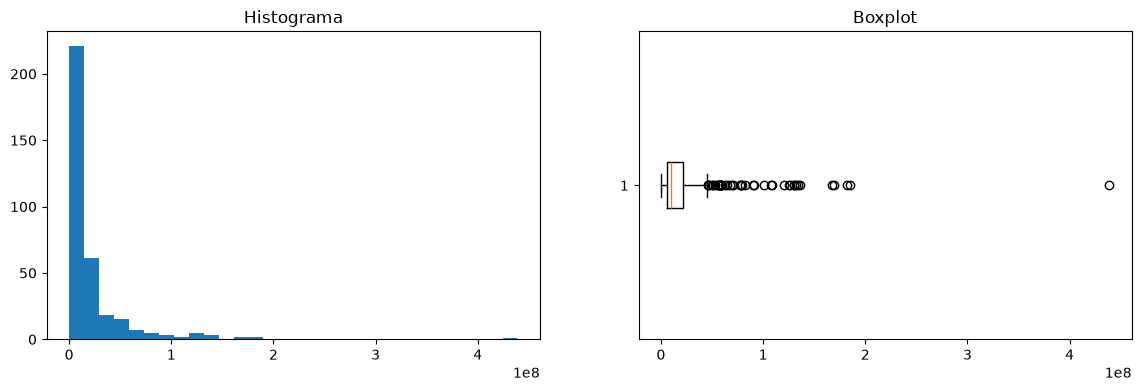

In [321]:
analizar_variable(
    df,
    "ingresos_municipales"
)

INGRESOS_MUNICIPALES

ANTES DEL LOG
---------------------------
Skewness : 5.4
Kurtosis : 45.628

DESPUÉS DEL LOG
---------------------------
Skewness : -5.709
Kurtosis : 40.788


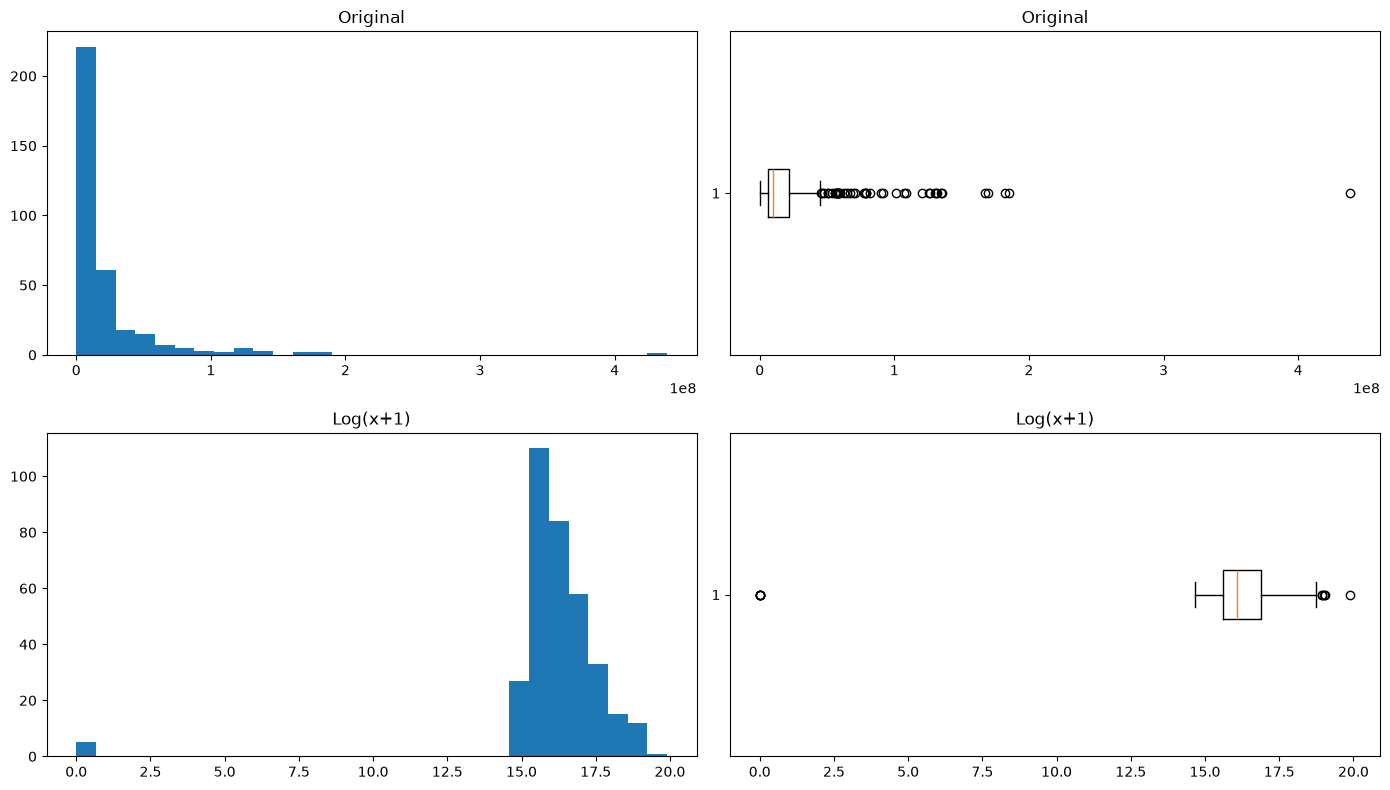

In [322]:
comparar_transformacion_log(
    df,
    "ingresos_municipales"
)

In [323]:
variables_economicas = [
    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc"
]

In [324]:
variables_capital_humano = [
    "promedio_escolaridad",
    "porcentaje_alfabetizacion"
]

In [325]:
variables_infraestructura = [
    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad"
]

variables_habitabilidad = [
    "porcentaje_hacinamiento",
    "promedio_personas_vivienda"
]

variables_conectividad = [
    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"
]

In [326]:
def auditar_familia(df, variables):

    resumen = []

    for variable in variables:

        resumen.append({

            "Variable": variable,

            "Nulos": df[variable].isna().sum(),

            "% Nulos": round(df[variable].isna().mean()*100,2),

            "Ceros": (df[variable]==0).sum(),

            "% Ceros": round((df[variable]==0).mean()*100,2),

            "Tipo": df[variable].dtype

        })

    return pd.DataFrame(resumen)

In [327]:
auditar_familia(
    df,
    variables_economicas
)

,Variable,Nulos,% Nulos,Ceros,% Ceros,Tipo
0,ingresos_municipales_pc,0,0.0,5,1.45,float64
1,ingresos_educacion_pc,0,0.0,101,29.28,float64
2,ingresos_salud_pc,0,0.0,29,8.41,float64


In [328]:
df.columns.tolist()

['anio',
 'codigo_comuna',
 'nombre_comuna',
 'codigo_provincia',
 'codigo_region',
 'nombre_region',
 'poblacion_total',
 'promedio_edad',
 'porcentaje_menores_15',
 'porcentaje_adultos_mayores',
 'porcentaje_discapacidad',
 'promedio_escolaridad',
 'porcentaje_alfabetizacion',
 'total_hogares',
 'porcentaje_computador',
 'porcentaje_internet_fija',
 'porcentaje_internet_movil',
 'total_viviendas',
 'promedio_personas_vivienda',
 'porcentaje_hacinamiento',
 'porcentaje_agua_red',
 'porcentaje_saneamiento',
 'porcentaje_electricidad',
 'ingresos_municipales',
 'ingresos_educacion',
 'ingresos_salud',
 'ingresos_municipales_pc',
 'ingresos_educacion_pc',
 'ingresos_salud_pc']

In [329]:
df["ingresos_municipales_pc"] = df["ingresos_municipales"] / df["poblacion_total"]
df["ingresos_educacion_pc"] = df["ingresos_educacion"] / df["poblacion_total"]
df["ingresos_salud_pc"] = df["ingresos_salud"] / df["poblacion_total"]

df[[
    "codigo_comuna",
    "nombre_comuna",
    "poblacion_total",
    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc"
]].head()

,codigo_comuna,nombre_comuna,poblacion_total,ingresos_municipales_pc,ingresos_educacion_pc,ingresos_salud_pc
0,1101,IQUIQUE,199587,507.820670,0.000000,214.757750
1,1107,ALTO HOSPICIO,142086,218.284074,0.000000,213.447750
2,1401,POZO ALMONTE,16878,996.793222,974.970316,258.284394
3,1402,CAMIÑA,1335,2633.059925,1798.261423,595.746816
4,1403,COLCHANE,790,4275.967089,1919.739241,1663.749367


In [330]:
variables_economicas = [
    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc"
]

auditar_familia(df, variables_economicas)

,Variable,Nulos,% Nulos,Ceros,% Ceros,Tipo
0,ingresos_municipales_pc,0,0.0,5,1.45,float64
1,ingresos_educacion_pc,0,0.0,101,29.28,float64
2,ingresos_salud_pc,0,0.0,29,8.41,float64


Económica
- ingresos_municipales_pc: usable
- ingresos_educacion_pc: problema conceptual / SLEP
- ingresos_salud_pc: requiere revisión

In [331]:
variables_capital_humano = [
    "promedio_escolaridad",
    "porcentaje_alfabetizacion"
]

variables_infraestructura = [
    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad"
]

variables_habitabilidad = [
    "porcentaje_hacinamiento",
    "promedio_personas_vivienda"
]

variables_conectividad = [
    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"
]

In [332]:
auditoria_familias = {
    "Económica": auditar_familia(df, variables_economicas),
    "Capital Humano": auditar_familia(df, variables_capital_humano),
    "Infraestructura": auditar_familia(df, variables_infraestructura),
    "Habitabilidad": auditar_familia(df, variables_habitabilidad),
    "Conectividad": auditar_familia(df, variables_conectividad),
}

auditoria_familias

{'Económica':                   Variable  Nulos  % Nulos  Ceros  % Ceros     Tipo
 0  ingresos_municipales_pc      0      0.0      5     1.45  float64
 1    ingresos_educacion_pc      0      0.0    101    29.28  float64
 2        ingresos_salud_pc      0      0.0     29     8.41  float64,
 'Capital Humano':                     Variable  Nulos  % Nulos  Ceros  % Ceros     Tipo
 0       promedio_escolaridad      0      0.0      0      0.0  float64
 1  porcentaje_alfabetizacion      0      0.0      0      0.0  float64,
 'Infraestructura':                   Variable  Nulos  % Nulos  Ceros  % Ceros     Tipo
 0      porcentaje_agua_red      0      0.0      0      0.0  float64
 1   porcentaje_saneamiento      0      0.0      0      0.0  float64
 2  porcentaje_electricidad      0      0.0      0      0.0  float64,
 'Habitabilidad':                      Variable  Nulos  % Nulos  Ceros  % Ceros     Tipo
 0     porcentaje_hacinamiento      0      0.0      1     0.29  float64
 1  promedio_personas

In [333]:
variables_desarrollo = [
    "promedio_escolaridad",
    "porcentaje_alfabetizacion",
    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad",
    "porcentaje_hacinamiento",
    "promedio_personas_vivienda",
    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"
]

In [334]:
def correlacion_variable(df, variable_objetivo, variables):

    correlaciones = []

    for variable in variables:

        r = df[variable_objetivo].corr(df[variable])

        correlaciones.append({
            "Variable": variable,
            "Correlación": round(r,3),
            "Valor absoluto": abs(r)
        })

    resultado = (
        pd.DataFrame(correlaciones)
        .sort_values("Valor absoluto", ascending=False)
        .reset_index(drop=True)
    )

    return resultado

In [335]:
correlacion_variable(
    df,
    "ingresos_municipales_pc",
    variables_desarrollo
)

,Variable,Correlación,Valor absoluto
0,porcentaje_electricidad,-0.579,0.579024
1,promedio_personas_vivienda,-0.474,0.474016
2,porcentaje_agua_red,-0.420,0.420481
3,porcentaje_saneamiento,-0.280,0.279901
4,porcentaje_internet_fija,-0.267,0.266578
5,porcentaje_hacinamiento,-0.259,0.258566
6,porcentaje_computador,-0.113,0.113232
7,porcentaje_internet_movil,-0.034,0.034185
8,promedio_escolaridad,0.024,0.024331
9,porcentaje_alfabetizacion,0.004,0.004354


In [336]:
def interpretar_correlacion(r):

    r_abs = abs(r)

    if r_abs >= 0.80:
        return "Muy fuerte"

    elif r_abs >= 0.60:
        return "Fuerte"

    elif r_abs >= 0.40:
        return "Moderada"

    elif r_abs >= 0.20:
        return "Débil"

    else:
        return "Muy débil"

In [337]:
def correlacion_variable(df, variable_objetivo, variables):

    correlaciones = []

    for variable in variables:

        r = df[variable_objetivo].corr(df[variable])

        correlaciones.append({

            "Variable": variable,
            "Correlación": round(r,3),
            "Valor absoluto": abs(r),
            "Interpretación": interpretar_correlacion(r)

        })

    return (
        pd.DataFrame(correlaciones)
        .sort_values("Valor absoluto", ascending=False)
        .reset_index(drop=True)
    )

In [338]:
correlacion_variable(
    df,
    "ingresos_municipales_pc",
    variables_desarrollo
)

,Variable,Correlación,Valor absoluto,Interpretación
0,porcentaje_electricidad,-0.579,0.579024,Moderada
1,promedio_personas_vivienda,-0.474,0.474016,Moderada
2,porcentaje_agua_red,-0.420,0.420481,Moderada
3,porcentaje_saneamiento,-0.280,0.279901,Débil
4,porcentaje_internet_fija,-0.267,0.266578,Débil
5,porcentaje_hacinamiento,-0.259,0.258566,Débil
6,porcentaje_computador,-0.113,0.113232,Muy débil
7,porcentaje_internet_movil,-0.034,0.034185,Muy débil
8,promedio_escolaridad,0.024,0.024331,Muy débil
9,porcentaje_alfabetizacion,0.004,0.004354,Muy débil


In [339]:
def interpretar_correlacion(r):

    r_abs = abs(r)

    if r_abs >= 0.80:
        return "Muy fuerte"

    elif r_abs >= 0.60:
        return "Fuerte"

    elif r_abs >= 0.40:
        return "Moderada"

    elif r_abs >= 0.20:
        return "Débil"

    else:
        return "Muy débil"

In [340]:
def interpretar_correlacion(r):
    r_abs = abs(r)

    if r_abs >= 0.80:
        return "Muy fuerte"
    elif r_abs >= 0.60:
        return "Fuerte"
    elif r_abs >= 0.40:
        return "Moderada"
    elif r_abs >= 0.20:
        return "Débil"
    else:
        return "Muy débil"


def correlacion_variable(df, variable_objetivo, variables):
    correlaciones = []

    for variable in variables:
        r = df[variable_objetivo].corr(df[variable])

        correlaciones.append({
            "Variable económica": variable_objetivo,
            "Variable desarrollo": variable,
            "Correlación": round(r, 3),
            "Valor absoluto": round(abs(r), 3),
            "Interpretación": interpretar_correlacion(r)
        })

    return (
        pd.DataFrame(correlaciones)
        .sort_values("Valor absoluto", ascending=False)
        .reset_index(drop=True)
    )

In [341]:
variables_economicas = [
    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc"
]

variables_desarrollo = [
    "promedio_escolaridad",
    "porcentaje_alfabetizacion",
    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad",
    "porcentaje_hacinamiento",
    "promedio_personas_vivienda",
    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"
]

resultado_correlaciones = pd.concat(
    [
        correlacion_variable(df, variable, variables_desarrollo)
        for variable in variables_economicas
    ],
    ignore_index=True
)

resultado_correlaciones

,Variable económica,Variable desarrollo,Correlación,Valor absoluto,Interpretación
0,ingresos_municipales_pc,porcentaje_electricidad,-0.579,0.579,Moderada
1,ingresos_municipales_pc,promedio_personas_vivienda,-0.474,0.474,Moderada
2,ingresos_municipales_pc,porcentaje_agua_red,-0.420,0.420,Moderada
3,ingresos_municipales_pc,porcentaje_saneamiento,-0.280,0.280,Débil
4,ingresos_municipales_pc,porcentaje_internet_fija,-0.267,0.267,Débil
5,ingresos_municipales_pc,porcentaje_hacinamiento,-0.259,0.259,Débil
6,ingresos_municipales_pc,porcentaje_computador,-0.113,0.113,Muy débil
7,ingresos_municipales_pc,porcentaje_internet_movil,-0.034,0.034,Muy débil
8,ingresos_municipales_pc,promedio_escolaridad,0.024,0.024,Muy débil
9,ingresos_municipales_pc,porcentaje_alfabetizacion,0.004,0.004,Muy débil


In [342]:
resultado_correlaciones.sort_values(
    ["Variable económica", "Valor absoluto"],
    ascending=[True, False]
)

,Variable económica,Variable desarrollo,Correlación,Valor absoluto,Interpretación
10,ingresos_educacion_pc,porcentaje_alfabetizacion,-0.396,0.396,Débil
11,ingresos_educacion_pc,promedio_escolaridad,-0.374,0.374,Débil
12,ingresos_educacion_pc,porcentaje_internet_movil,-0.358,0.358,Débil
13,ingresos_educacion_pc,porcentaje_computador,-0.350,0.350,Débil
14,ingresos_educacion_pc,porcentaje_saneamiento,-0.348,0.348,Débil
15,ingresos_educacion_pc,porcentaje_internet_fija,-0.348,0.348,Débil
16,ingresos_educacion_pc,porcentaje_agua_red,-0.293,0.293,Débil
17,ingresos_educacion_pc,promedio_personas_vivienda,-0.229,0.229,Débil
18,ingresos_educacion_pc,porcentaje_electricidad,-0.205,0.205,Débil
19,ingresos_educacion_pc,porcentaje_hacinamiento,-0.101,0.101,Muy débil


In [343]:
pivot = resultado_correlaciones.pivot(
    index="Variable desarrollo",
    columns="Variable económica",
    values="Correlación"
)

pivot

Variable económica,ingresos_educacion_pc,ingresos_municipales_pc,ingresos_salud_pc
Variable desarrollo,,,
porcentaje_agua_red,-0.293,-0.420,-0.457
porcentaje_alfabetizacion,-0.396,0.004,-0.148
porcentaje_computador,-0.350,-0.113,-0.276
porcentaje_electricidad,-0.205,-0.579,-0.540
porcentaje_hacinamiento,-0.101,-0.259,-0.213
porcentaje_internet_fija,-0.348,-0.267,-0.341
porcentaje_internet_movil,-0.358,-0.034,-0.191
porcentaje_saneamiento,-0.348,-0.280,-0.367
promedio_escolaridad,-0.374,0.024,-0.120


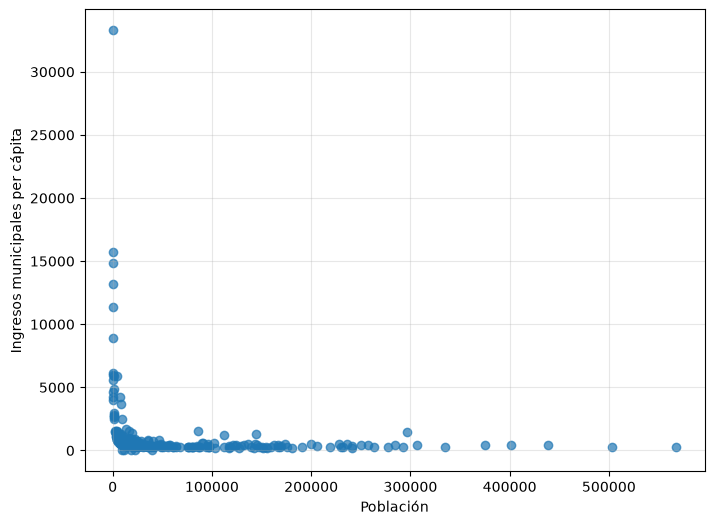

In [344]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_municipales_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos municipales per cápita")

plt.grid(alpha=0.3)

plt.show()

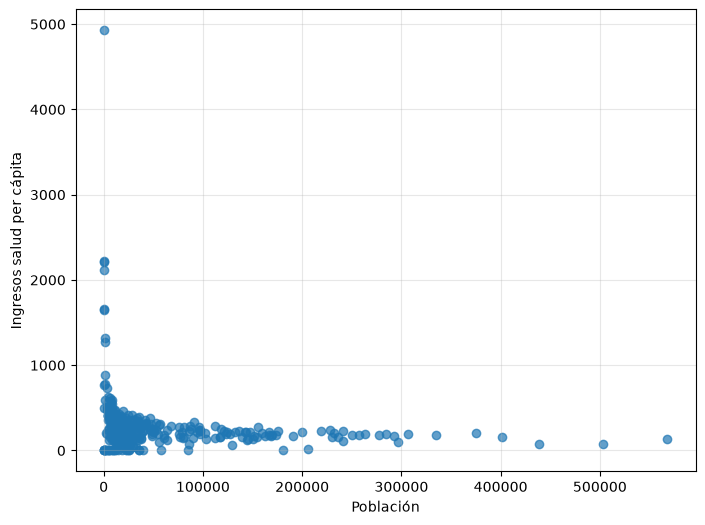

In [345]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_salud_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos salud per cápita")

plt.grid(alpha=0.3)

plt.show()

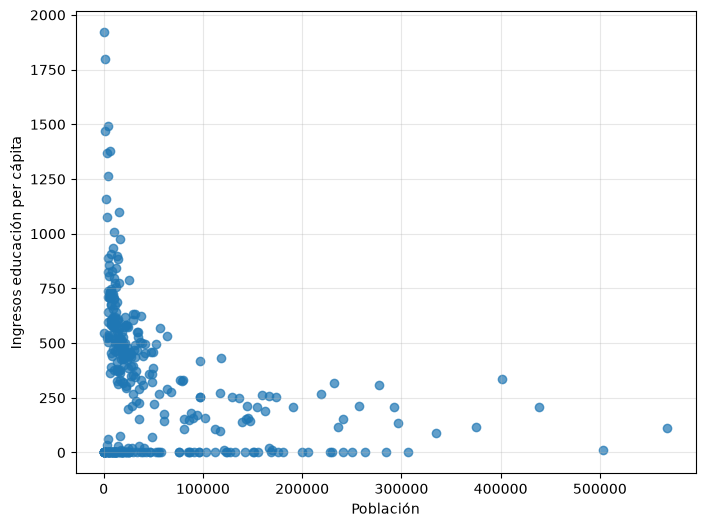

In [346]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_educacion_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos educación per cápita")

plt.grid(alpha=0.3)

plt.show()

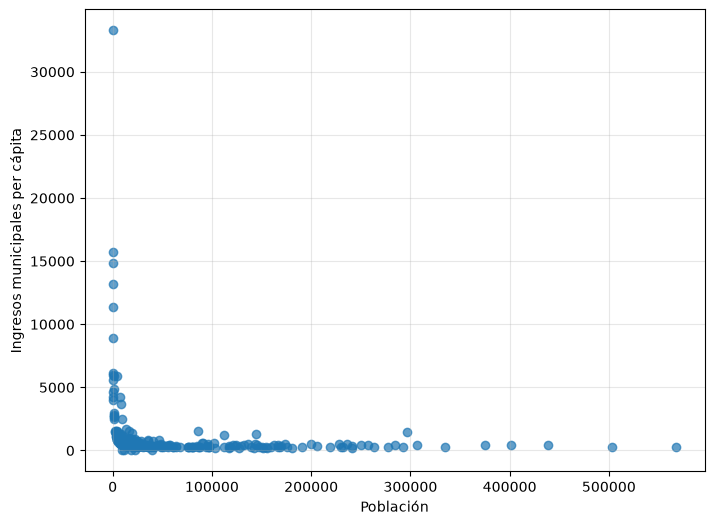

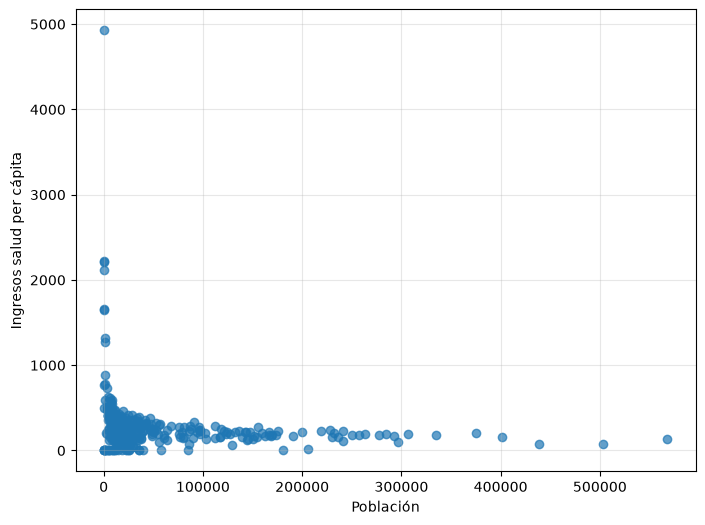

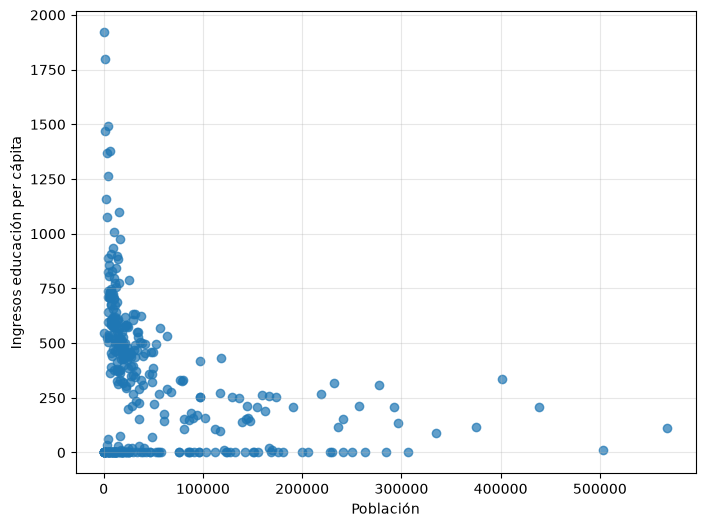

In [347]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_municipales_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos municipales per cápita")

plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_salud_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos salud per cápita")

plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8,6))

plt.scatter(
    df["poblacion_total"],
    df["ingresos_educacion_pc"],
    alpha=0.7
)

plt.xlabel("Población")
plt.ylabel("Ingresos educación per cápita")

plt.grid(alpha=0.3)

plt.show()

In [348]:
variables = [
    "ingresos_municipales_pc",
    "ingresos_salud_pc",
    "ingresos_educacion_pc"
]

for v in variables:

    print("="*60)
    print(v)
    print("="*60)

    print(
        df["poblacion_total"].corr(df[v])
    )

ingresos_municipales_pc
-0.1565395816413748
ingresos_salud_pc
-0.185832331065743
ingresos_educacion_pc
-0.30430263952924275


In [349]:
variables = [
    "ingresos_municipales_pc",
    "ingresos_salud_pc",
    "ingresos_educacion_pc"
]

for v in variables:

    r = df["poblacion_total"].corr(
        df[v],
        method="spearman"
    )

    print("="*60)
    print(v)
    print("="*60)
    print(round(r,3))

ingresos_municipales_pc
-0.746
ingresos_salud_pc
-0.414
ingresos_educacion_pc
-0.294


| Variable    | Pearson | Spearman | Conclusión                                                                                                                            |
| ----------- | ------: | -------: | ------------------------------------------------------------------------------------------------------------------------------------- |
| Municipales |  -0.157 |   -0.746 | Relación monotónica fuerte; el indicador per cápita disminuye sistemáticamente al aumentar la población.                              |
| Salud       |  -0.186 |   -0.414 | Relación monotónica moderada.                                                                                                         |
| Educación   |  -0.304 |   -0.294 | Relación débil y estable; la variable parece estar condicionada por cambios administrativos (SLEP) más que por el tamaño poblacional. |


In [350]:
variables_iidc = [

    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc",

    "promedio_escolaridad",
    "porcentaje_alfabetizacion",

    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad",

    "porcentaje_hacinamiento",
    "promedio_personas_vivienda",

    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"

]

In [351]:
corr = df[variables_iidc].corr()

corr

,ingresos_municipales_pc,ingresos_educacion_pc,ingresos_salud_pc,promedio_escolaridad,porcentaje_alfabetizacion,porcentaje_agua_red,porcentaje_saneamiento,porcentaje_electricidad,porcentaje_hacinamiento,promedio_personas_vivienda,porcentaje_computador,porcentaje_internet_fija,porcentaje_internet_movil
ingresos_municipales_pc,1.000000,-0.018443,0.846074,0.024331,0.004354,-0.420481,-0.279901,-0.579024,-0.258566,-0.474016,-0.113232,-0.266578,-0.034185
ingresos_educacion_pc,-0.018443,1.000000,0.092902,-0.373760,-0.395876,-0.293397,-0.348384,-0.205091,-0.101409,-0.229376,-0.350332,-0.347682,-0.358443
ingresos_salud_pc,0.846074,0.092902,1.000000,-0.120398,-0.147718,-0.457023,-0.366759,-0.539785,-0.213153,-0.432960,-0.275796,-0.340767,-0.190991
promedio_escolaridad,0.024331,-0.373760,-0.120398,1.000000,0.846654,0.438586,0.587698,0.237279,-0.071144,0.213327,0.908739,0.742638,0.717800
porcentaje_alfabetizacion,0.004354,-0.395876,-0.147718,0.846654,1.000000,0.398845,0.532063,0.173926,0.046460,0.203516,0.765584,0.657788,0.730268
porcentaje_agua_red,-0.420481,-0.293397,-0.457023,0.438586,0.398845,1.000000,0.811797,0.885463,0.471969,0.884897,0.598568,0.740835,0.466703
porcentaje_saneamiento,-0.279901,-0.348384,-0.366759,0.587698,0.532063,0.811797,1.000000,0.693235,0.403626,0.724455,0.676343,0.842081,0.465775
porcentaje_electricidad,-0.579024,-0.205091,-0.539785,0.237279,0.173926,0.885463,0.693235,1.000000,0.447608,0.935678,0.432266,0.586869,0.310667
porcentaje_hacinamiento,-0.258566,-0.101409,-0.213153,-0.071144,0.046460,0.471969,0.403626,0.447608,1.000000,0.576990,0.042502,0.259812,0.048960
promedio_personas_vivienda,-0.474016,-0.229376,-0.432960,0.213327,0.203516,0.884897,0.724455,0.935678,0.576990,1.000000,0.425277,0.626247,0.321557


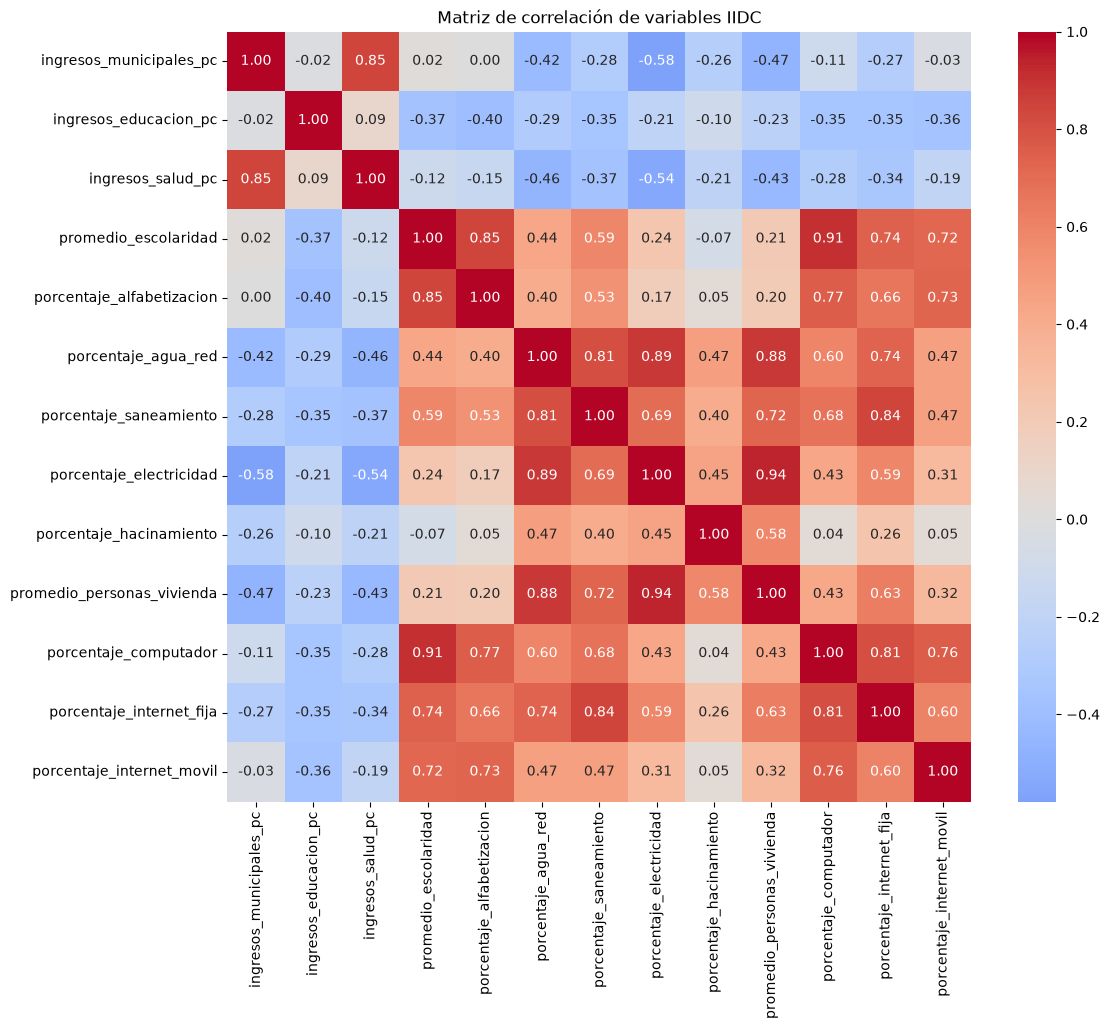

In [352]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de variables IIDC")

plt.show()

In [353]:
corr = df[variables_iidc].corr()

corr_unstack = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .unstack()
        .dropna()
        .reset_index()
)

corr_unstack.columns = [
    "Variable_1",
    "Variable_2",
    "Correlacion"
]

corr_unstack["Abs"] = corr_unstack["Correlacion"].abs()

corr_unstack = (
    corr_unstack
    .query("Abs >= 0.80")
    .sort_values("Abs", ascending=False)
)

corr_unstack

,Variable_1,Variable_2,Correlacion,Abs
92,porcentaje_electricidad,promedio_personas_vivienda,0.935678,0.935678
115,promedio_personas_vivienda,porcentaje_electricidad,0.935678,0.935678
45,promedio_escolaridad,porcentaje_computador,0.908739,0.908739
123,porcentaje_computador,promedio_escolaridad,0.908739,0.908739
89,porcentaje_electricidad,porcentaje_agua_red,0.885463,0.885463
66,porcentaje_agua_red,porcentaje_electricidad,0.885463,0.885463
68,porcentaje_agua_red,promedio_personas_vivienda,0.884897,0.884897
113,promedio_personas_vivienda,porcentaje_agua_red,0.884897,0.884897
39,promedio_escolaridad,porcentaje_alfabetizacion,0.846654,0.846654
51,porcentaje_alfabetizacion,promedio_escolaridad,0.846654,0.846654


In [354]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [355]:
variables = [

    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc",

    "promedio_escolaridad",
    "porcentaje_alfabetizacion",

    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad",

    "porcentaje_hacinamiento",
    "promedio_personas_vivienda",

    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"

]

X = df[variables]

In [356]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
3,promedio_escolaridad,1101.897191
4,porcentaje_alfabetizacion,1094.727647
12,porcentaje_internet_movil,547.342859
9,promedio_personas_vivienda,265.712250
7,porcentaje_electricidad,261.395211
10,porcentaje_computador,168.384212
5,porcentaje_agua_red,87.009383
11,porcentaje_internet_fija,29.683797
6,porcentaje_saneamiento,28.782826
8,porcentaje_hacinamiento,12.708322


In [357]:
def interpretar_vif(v):

    if v < 3:
        return "Bajo"

    elif v < 5:
        return "Moderado"

    elif v < 10:
        return "Alto"

    else:
        return "Muy alto"

vif["Interpretación"] = vif["VIF"].apply(interpretar_vif)

vif

,Variable,VIF,Interpretación
3,promedio_escolaridad,1101.897191,Muy alto
4,porcentaje_alfabetizacion,1094.727647,Muy alto
12,porcentaje_internet_movil,547.342859,Muy alto
9,promedio_personas_vivienda,265.712250,Muy alto
7,porcentaje_electricidad,261.395211,Muy alto
10,porcentaje_computador,168.384212,Muy alto
5,porcentaje_agua_red,87.009383,Muy alto
11,porcentaje_internet_fija,29.683797,Muy alto
6,porcentaje_saneamiento,28.782826,Muy alto
8,porcentaje_hacinamiento,12.708322,Muy alto


El análisis mediante el Factor de Inflación de la Varianza (VIF) evidenció niveles extremadamente altos de multicolinealidad entre varias variables utilizadas para construir el IIDC.

Particularmente, las variables relacionadas con capital humano (escolaridad y alfabetización), conectividad (computador e internet) e infraestructura básica (agua, electricidad y saneamiento) presentan VIF superiores a 25 e incluso superiores a 1000 en algunos casos.

Este comportamiento indica que gran parte de estas variables describen dimensiones comunes del desarrollo comunal, por lo que su utilización simultánea dentro de un índice compuesto podría otorgar un peso excesivo a un mismo fenómeno.

¿Coinciden las dimensiones estadísticas con las dimensiones teóricas?

In [358]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [359]:
variables_iidc = [

    "ingresos_municipales_pc",
    "ingresos_educacion_pc",
    "ingresos_salud_pc",

    "promedio_escolaridad",
    "porcentaje_alfabetizacion",

    "porcentaje_agua_red",
    "porcentaje_saneamiento",
    "porcentaje_electricidad",

    "porcentaje_hacinamiento",
    "promedio_personas_vivienda",

    "porcentaje_computador",
    "porcentaje_internet_fija",
    "porcentaje_internet_movil"

]

X = df[variables_iidc]

In [360]:
scaler = StandardScaler()

X_std = scaler.fit_transform(X)

In [361]:
pca = PCA()

X_pca = pca.fit_transform(X_std)

In [362]:
import pandas as pd

varianza = pd.DataFrame({

    "Componente":

        [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],

    "Varianza Explicada":

        pca.explained_variance_ratio_,

    "Varianza Acumulada":

        pca.explained_variance_ratio_.cumsum()

})

varianza

,Componente,Varianza Explicada,Varianza Acumulada
0,PC1,0.500440,0.500440
1,PC2,0.207496,0.707936
2,PC3,0.091198,0.799134
3,PC4,0.060782,0.859916
4,PC5,0.044754,0.904670
5,PC6,0.033325,0.937995
6,PC7,0.015088,0.953084
7,PC8,0.013893,0.966976
8,PC9,0.012123,0.979100
9,PC10,0.007981,0.987080


¿Qué está midiendo realmente cada componente?

In [363]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(variables_iidc))],
    index=variables_iidc
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
ingresos_municipales_pc,-0.164305,0.397302,0.513316,0.109975,-0.115138,0.063226,-0.169516,0.160041,-0.473377,-0.376610,-0.213375,-0.236539,-0.023750
ingresos_educacion_pc,-0.168909,-0.158801,-0.172288,0.935821,0.169605,0.042585,0.038411,0.074568,-0.042422,-0.005314,-0.016876,-0.029347,0.014786
ingresos_salud_pc,-0.200870,0.298959,0.570312,0.185482,-0.172936,0.053187,0.231000,-0.166652,0.459620,0.332623,0.172691,0.189950,-0.094623
promedio_escolaridad,0.280158,0.379087,-0.120360,0.104201,0.018066,-0.177189,0.081007,-0.419206,-0.119001,0.228199,0.180815,-0.500411,0.434857
porcentaje_alfabetizacion,0.264666,0.355737,-0.098598,-0.020759,0.347604,-0.054810,0.713696,0.272756,-0.012837,-0.133305,-0.188711,0.102218,-0.147193
porcentaje_agua_red,0.348163,-0.167316,0.160455,0.086819,-0.187672,0.109227,0.167898,0.068136,-0.241222,-0.308294,0.727121,0.221643,0.080358
porcentaje_saneamiento,0.346142,-0.027117,0.169779,0.088299,-0.088105,-0.428169,-0.208006,0.528364,-0.176834,0.535984,-0.040491,0.095465,0.000795
porcentaje_electricidad,0.306267,-0.308593,0.080181,0.057822,-0.325601,0.226154,0.220211,-0.143730,-0.075628,0.151774,-0.156815,-0.459178,-0.557400
porcentaje_hacinamiento,0.151158,-0.299144,0.461501,-0.054640,0.765596,-0.033234,-0.119679,-0.231920,-0.047278,0.032494,0.044272,-0.073528,-0.075414
promedio_personas_vivienda,0.308008,-0.291723,0.244907,0.065605,-0.186898,0.200204,0.145475,-0.050975,0.120416,-0.094009,-0.499257,0.162774,0.598231


In [364]:
loadings[["PC1","PC2","PC3","PC4"]]

,PC1,PC2,PC3,PC4
ingresos_municipales_pc,-0.164305,0.397302,0.513316,0.109975
ingresos_educacion_pc,-0.168909,-0.158801,-0.172288,0.935821
ingresos_salud_pc,-0.200870,0.298959,0.570312,0.185482
promedio_escolaridad,0.280158,0.379087,-0.120360,0.104201
porcentaje_alfabetizacion,0.264666,0.355737,-0.098598,-0.020759
porcentaje_agua_red,0.348163,-0.167316,0.160455,0.086819
porcentaje_saneamiento,0.346142,-0.027117,0.169779,0.088299
porcentaje_electricidad,0.306267,-0.308593,0.080181,0.057822
porcentaje_hacinamiento,0.151158,-0.299144,0.461501,-0.054640
promedio_personas_vivienda,0.308008,-0.291723,0.244907,0.065605


Conclusión 1

Existe una dimensión general del desarrollo comunal (PC1) que combina infraestructura, conectividad y capital humano.

Conclusión 2
Los ingresos municipales y de salud comparten una dimensión económica distinta (PC3).

Conclusión 3
Los ingresos en educación constituyen una dimensión prácticamente independiente (PC4), probablemente influenciada por el cambio institucional hacia los SLEP.

Conclusión 4
La estructura empírica obtenida mediante PCA no coincide exactamente con la clasificación teórica inicial de las variables.

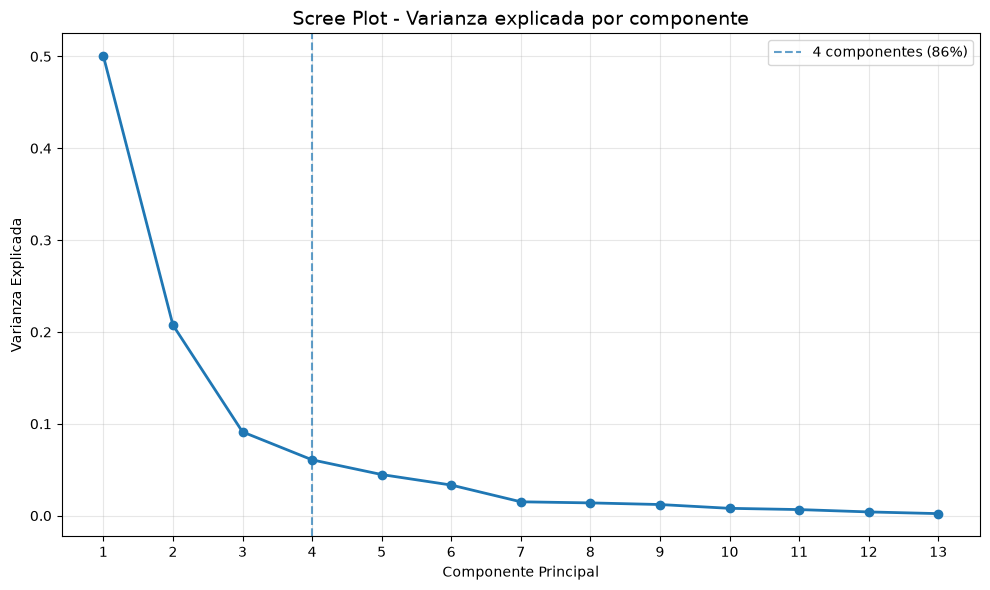

In [365]:
plt.figure(figsize=(10,6))

x = range(1, len(pca.explained_variance_ratio_) + 1)
y = pca.explained_variance_ratio_

plt.plot(x, y, marker="o", linewidth=2)

plt.axvline(
    x=4,
    linestyle="--",
    alpha=0.7,
    label="4 componentes (86%)"
)

plt.title("Scree Plot - Varianza explicada por componente", fontsize=14)

plt.xlabel("Componente Principal")

plt.ylabel("Varianza Explicada")

plt.xticks(x)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

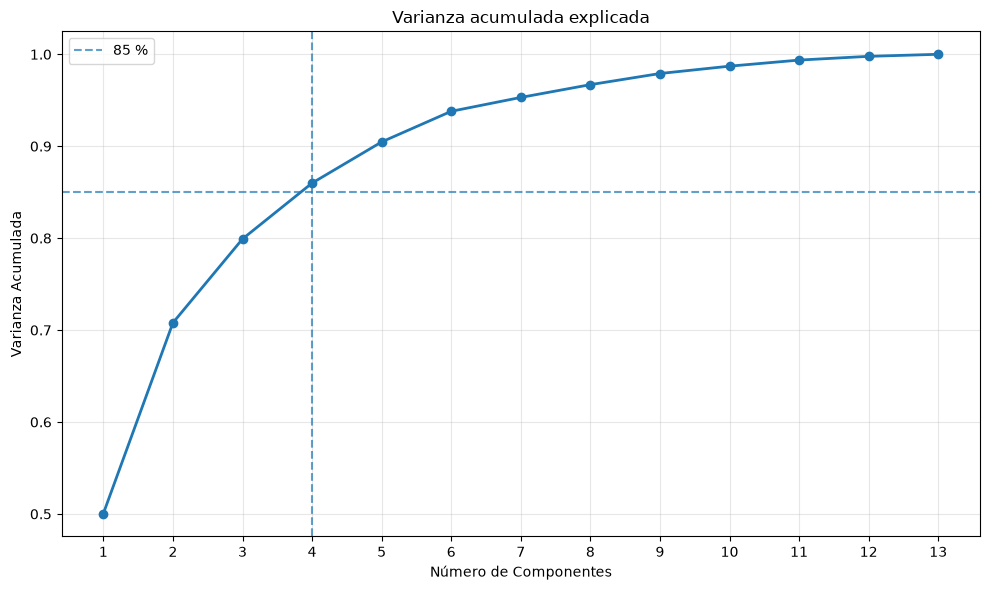

In [366]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0.85,
    linestyle="--",
    alpha=0.7,
    label="85 %"
)

plt.axvline(
    x=4,
    linestyle="--",
    alpha=0.7
)

plt.title("Varianza acumulada explicada")

plt.xlabel("Número de Componentes")

plt.ylabel("Varianza Acumulada")

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()